YOUTUBE CHANNELS ANALYSIS PROJECT - (2005 - 2019)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("most_subscribed_youtube_channels.csv")
df

,rank,Youtuber,subscribers,video views,video count,category,started
0,1,T-Series,"222,000,000","198,459,090,822","17,317",Music,2006
1,2,YouTube Movies,"154,000,000",0,0,Film & Animation,2015
2,3,Cocomelon - Nursery Rhymes,"140,000,000","135,481,339,848",786,Education,2006
3,4,SET India,"139,000,000","125,764,252,686","91,271",Shows,2006
4,5,Music,"116,000,000",0,0,NaN,2013
...,...,...,...,...,...,...,...
995,996,JP Plays,"10,900,000","4,609,300,218","3,528",Gaming,2014
996,997,TrapMusicHDTV,"10,900,000","4,070,521,973",690,Music,2013
997,998,Games EduUu,"10,900,000","3,093,784,767","1,006",Gaming,2011
998,999,Hueva,"10,900,000","3,040,301,750",831,Gaming,2012


In [3]:
df.shape

(1000, 7)

In [4]:
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'video count',
       'category', 'started'],
      dtype='object')

In [5]:
df.index

RangeIndex(start=0, stop=1000, step=1)

In [6]:
df.head()

,rank,Youtuber,subscribers,video views,video count,category,started
0,1,T-Series,"222,000,000","198,459,090,822","17,317",Music,2006
1,2,YouTube Movies,"154,000,000",0,0,Film & Animation,2015
2,3,Cocomelon - Nursery Rhymes,"140,000,000","135,481,339,848",786,Education,2006
3,4,SET India,"139,000,000","125,764,252,686","91,271",Shows,2006
4,5,Music,"116,000,000",0,0,NaN,2013


In [7]:
df.tail()

,rank,Youtuber,subscribers,video views,video count,category,started
995,996,JP Plays,"10,900,000","4,609,300,218","3,528",Gaming,2014
996,997,TrapMusicHDTV,"10,900,000","4,070,521,973",690,Music,2013
997,998,Games EduUu,"10,900,000","3,093,784,767","1,006",Gaming,2011
998,999,Hueva,"10,900,000","3,040,301,750",831,Gaming,2012
999,1000,Dobre Brothers,"10,900,000","2,808,411,693",590,People & Blogs,2017


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   rank         1000 non-null   int64 
 1   Youtuber     1000 non-null   object
 2   subscribers  1000 non-null   object
 3   video views  1000 non-null   object
 4   video count  1000 non-null   object
 5   category     973 non-null    object
 6   started      1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


In [9]:
df['subscribers'] = df['subscribers'].str.replace(',', '')

In [10]:
df['video views'] = df['video views'].str.replace(',', '')

In [11]:
df['video count'] = df['video count'].str.replace(',', '')

In [12]:
df['subscribers'] = df['subscribers'].astype(int)

In [13]:
df['video views'] = df['video views'].astype('int64')

In [14]:
df['video count'] = df['video count'].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   rank         1000 non-null   int64 
 1   Youtuber     1000 non-null   object
 2   subscribers  1000 non-null   int32 
 3   video views  1000 non-null   int64 
 4   video count  1000 non-null   int32 
 5   category     973 non-null    object
 6   started      1000 non-null   int64 
dtypes: int32(2), int64(3), object(2)
memory usage: 47.0+ KB


In [17]:
df.groupby("rank")[["Youtuber","subscribers","video views","video count"]].sum()

,Youtuber,subscribers,video views,video count
rank,,,,
1,T-Series,222000000,198459090822,17317
2,YouTube Movies,154000000,0,0
3,Cocomelon - Nursery Rhymes,140000000,135481339848,786
4,SET India,139000000,125764252686,91271
5,Music,116000000,0,0
...,...,...,...,...
996,JP Plays,10900000,4609300218,3528
997,TrapMusicHDTV,10900000,4070521973,690
998,Games EduUu,10900000,3093784767,1006


<Axes: xlabel='started'>

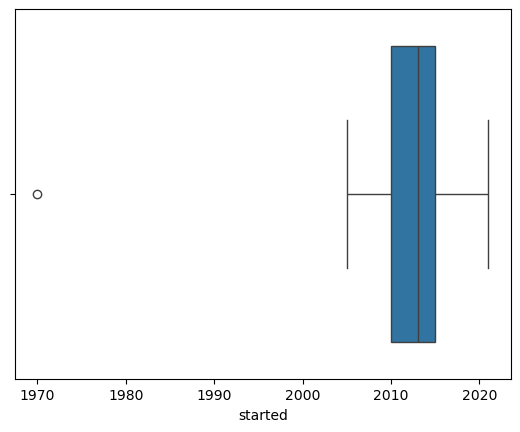

In [19]:
sns.boxplot(x='started',data=df)

<Axes: xlabel='started', ylabel='Count'>

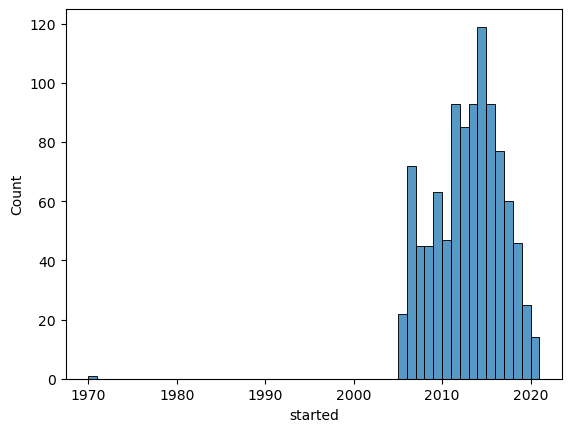

In [20]:
sns.histplot(x='started',data=df)

<Axes: xlabel='subscribers'>

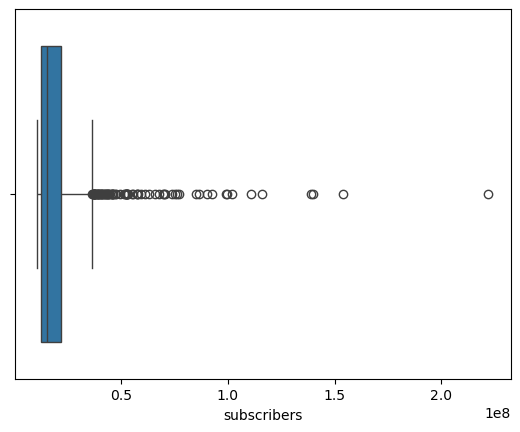

In [21]:
sns.boxplot(x='subscribers',data=df)

<Axes: xlabel='subscribers', ylabel='Count'>

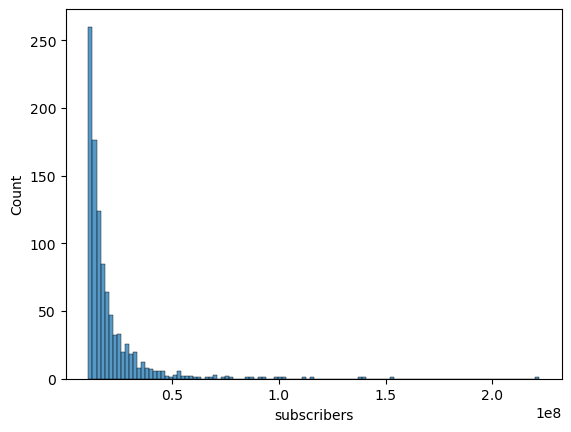

In [22]:
sns.histplot(x='subscribers',data=df)

In [23]:
def replace_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])

In [24]:
replace_outliers(df, 'started')

<Axes: xlabel='started'>

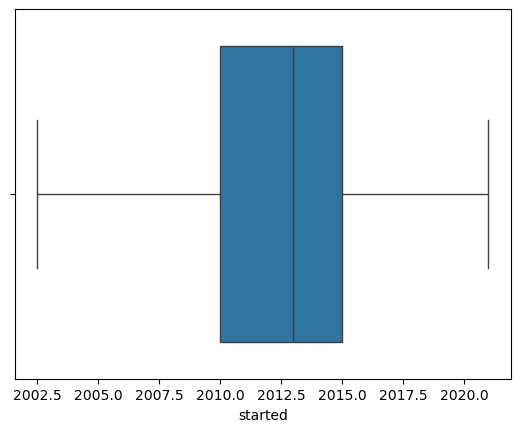

In [25]:
sns.boxplot(x='started',data=df)

<Axes: xlabel='subscribers', ylabel='Count'>

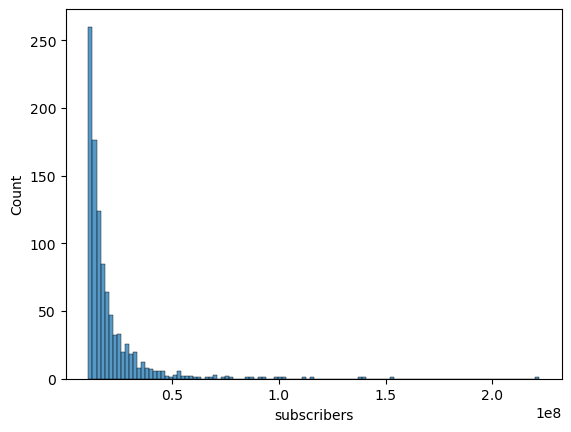

In [26]:
sns.histplot(x='subscribers',data=df)

In [27]:
replace_outliers(df, 'subscribers')

<Axes: xlabel='subscribers'>

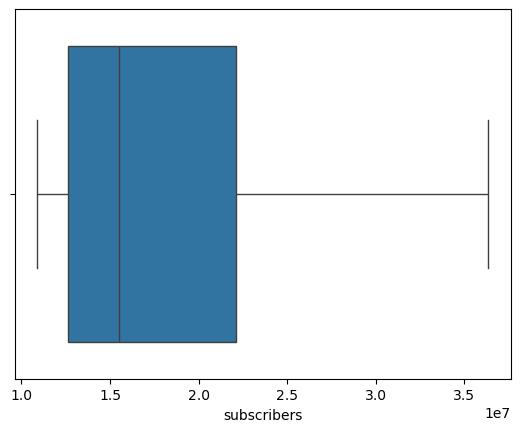

In [28]:
sns.boxplot(x='subscribers',data=df)

<Axes: xlabel='subscribers', ylabel='Count'>

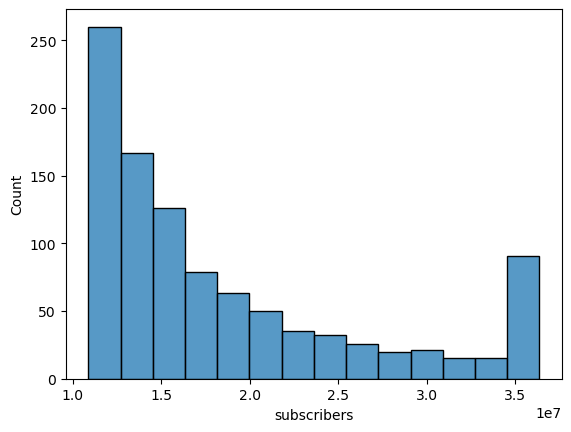

In [29]:
sns.histplot(x='subscribers',data=df)

<Axes: xlabel='video count', ylabel='category'>

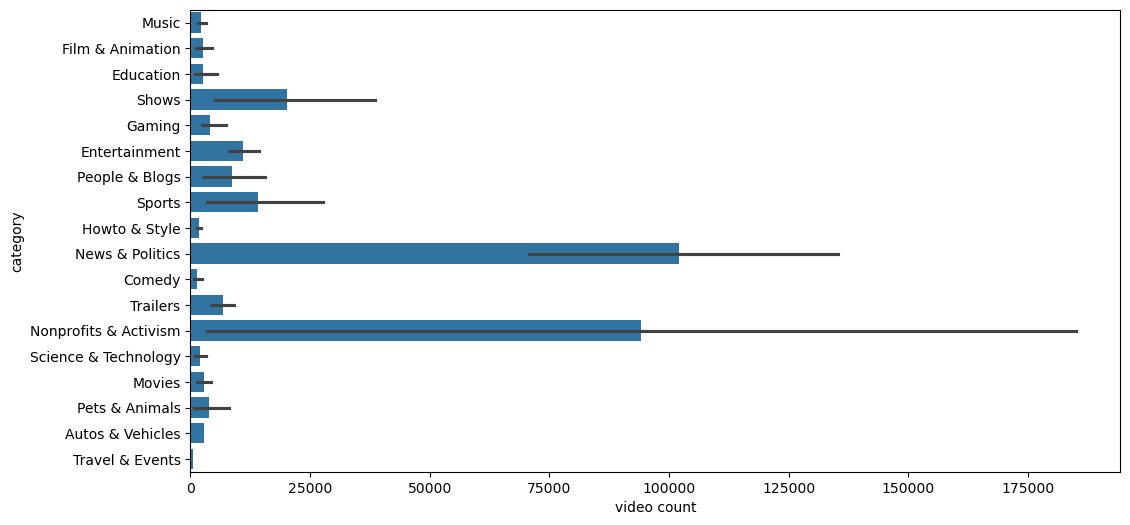

In [30]:
plt.figure(figsize=(12, 6)) 
sns.barplot(y="category",x="video count",data=df)

<Axes: xlabel='video views', ylabel='category'>

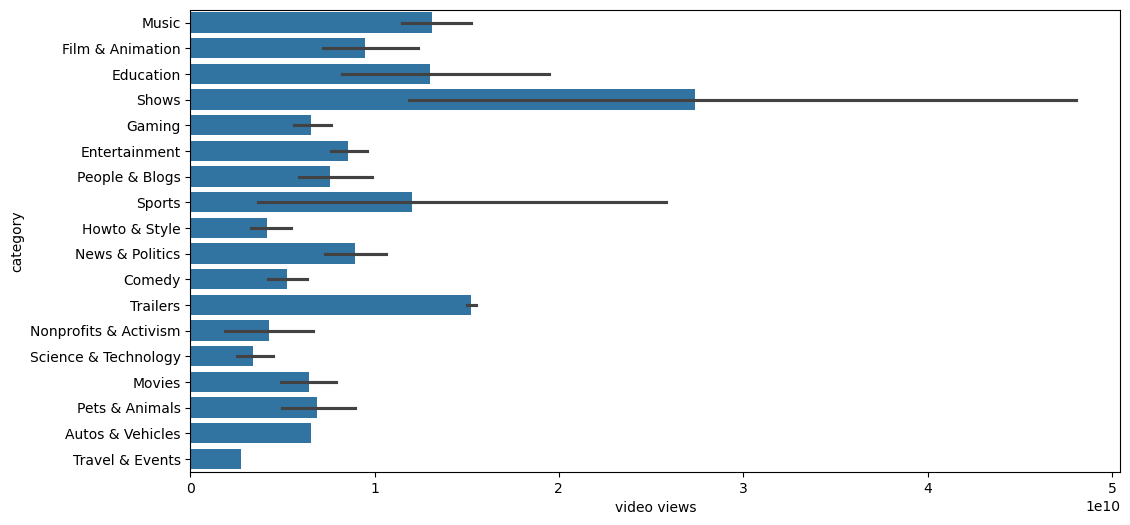

In [31]:
plt.figure(figsize=(12, 6)) 
sns.barplot(y="category",x="video views",data=df)

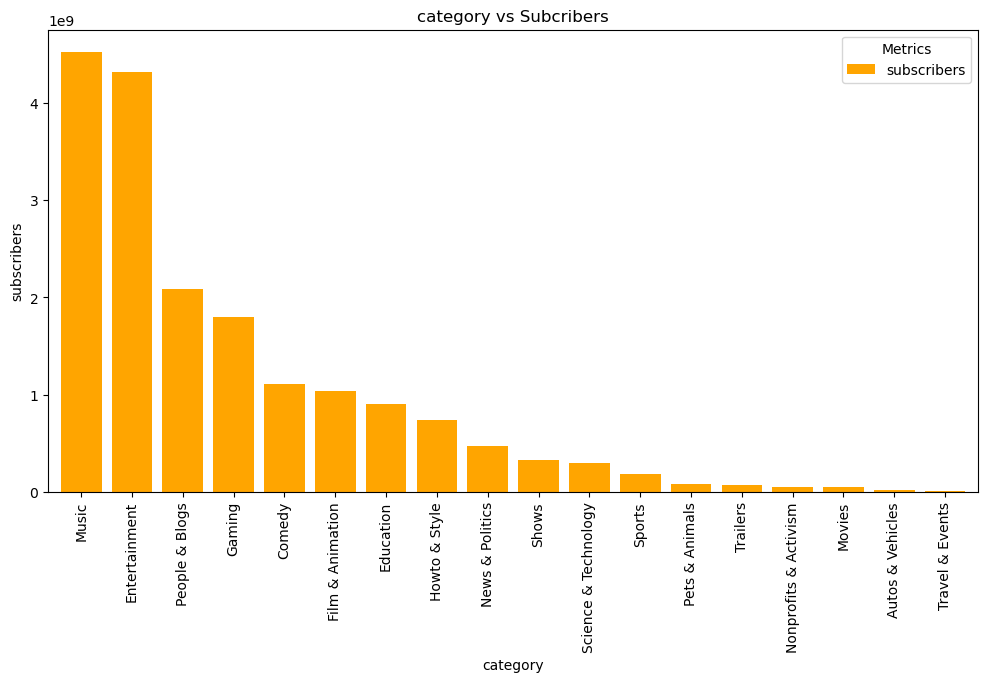

In [32]:
data=df.groupby("category")["subscribers"].sum().sort_values(ascending=False)
data.plot(kind="bar", color=["orange"],figsize=(12, 6), width=0.8)
plt.xlabel("category")
plt.ylabel("subscribers")
plt.title("category vs Subcribers")
plt.legend(title="Metrics")
plt.show()

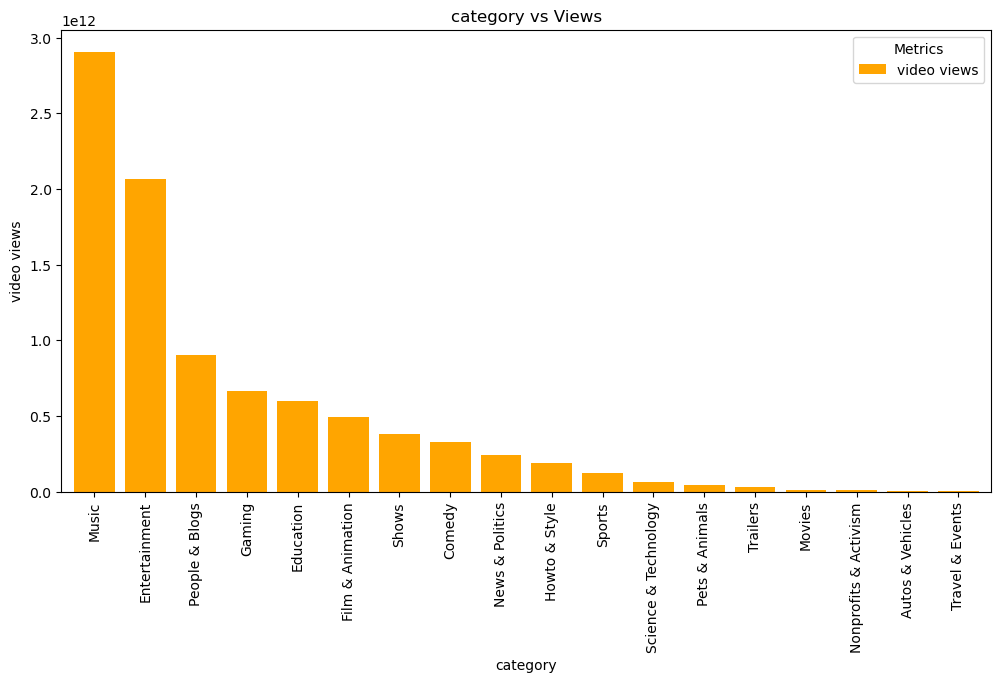

In [33]:
data=df.groupby("category")["video views"].sum().sort_values(ascending=False)
data.plot(kind="bar", color=["orange"],figsize=(12, 6), width=0.8)
plt.xlabel("category")
plt.ylabel("video views")
plt.title("category vs Views")
plt.legend(title="Metrics")
plt.show()

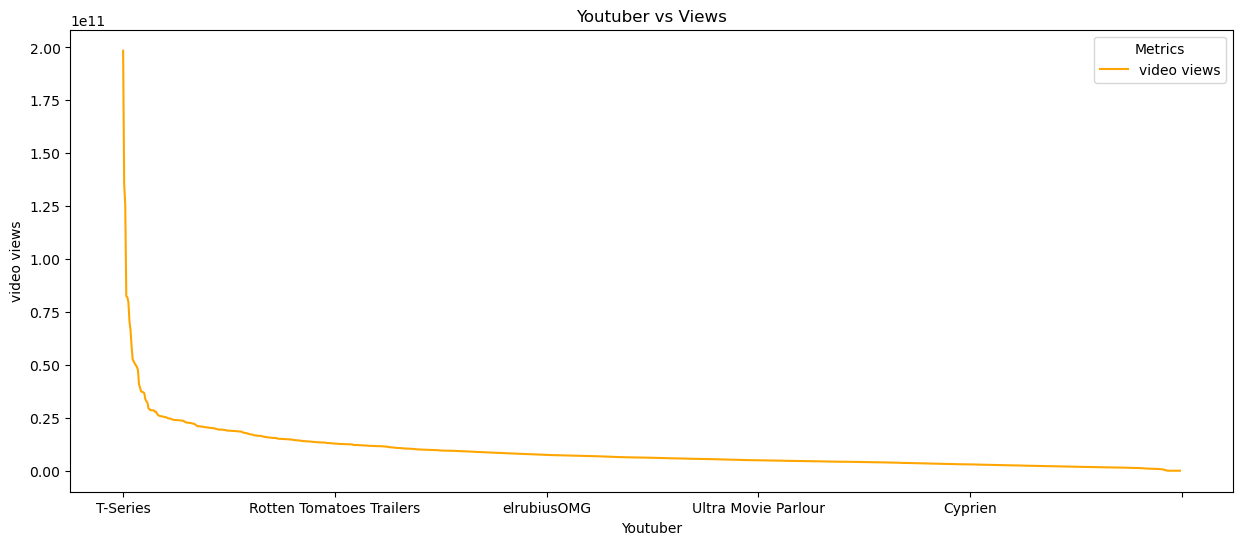

In [34]:
data=df.groupby("Youtuber")["video views"].mean().sort_values(ascending=False)
data.plot(kind="line", color=["orange"],figsize=(15, 6))
plt.xlabel("Youtuber")
plt.ylabel("video views")
plt.title("Youtuber vs Views")
plt.legend(title="Metrics")
plt.show()